# MSc Project

# AI-Powered Intrusion Detection Systems (IDS) for Network Anomaly Detection

# RT-IoT2022 Dataset 

## Part 1: Data Exploration

### System Check

In [87]:
# Showing all the software programs are correct installted.
# Checking the versions of all programs


import sys 
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib as pl
import joblib as job

print("Python:", sys.version)
print("numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sk.__version__)
print("Matplotlib:", pl.__version__)
print("Joblib:", job.__version__)


Python: 3.14.4 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 17:00:17) [MSC v.1942 64 bit (AMD64)]
numpy: 2.4.4
Pandas: 3.0.2
scikit-learn: 1.8.0
Matplotlib: 3.10.8
Joblib: 1.5.3


# Starting working with the dataset

### Confirm the notebook is running from the correct place

In [9]:
import os
print(os.getcwd())

C:\Users\muaz9\AI_IDS_RT_IoT2022\notebooks


### Dataset Inspection

In [10]:
import pandas as pan
df = pan.read_csv("../data/raw/RT_IoT2022.csv")
df.head()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


### Checking columns

In [12]:
df.columns.tolist()

['Unnamed: 0',
 'id.orig_p',
 'id.resp_p',
 'proto',
 'service',
 'flow_duration',
 'fwd_pkts_tot',
 'bwd_pkts_tot',
 'fwd_data_pkts_tot',
 'bwd_data_pkts_tot',
 'fwd_pkts_per_sec',
 'bwd_pkts_per_sec',
 'flow_pkts_per_sec',
 'down_up_ratio',
 'fwd_header_size_tot',
 'fwd_header_size_min',
 'fwd_header_size_max',
 'bwd_header_size_tot',
 'bwd_header_size_min',
 'bwd_header_size_max',
 'flow_FIN_flag_count',
 'flow_SYN_flag_count',
 'flow_RST_flag_count',
 'fwd_PSH_flag_count',
 'bwd_PSH_flag_count',
 'flow_ACK_flag_count',
 'fwd_URG_flag_count',
 'bwd_URG_flag_count',
 'flow_CWR_flag_count',
 'flow_ECE_flag_count',
 'fwd_pkts_payload.min',
 'fwd_pkts_payload.max',
 'fwd_pkts_payload.tot',
 'fwd_pkts_payload.avg',
 'fwd_pkts_payload.std',
 'bwd_pkts_payload.min',
 'bwd_pkts_payload.max',
 'bwd_pkts_payload.tot',
 'bwd_pkts_payload.avg',
 'bwd_pkts_payload.std',
 'flow_pkts_payload.min',
 'flow_pkts_payload.max',
 'flow_pkts_payload.tot',
 'flow_pkts_payload.avg',
 'flow_pkts_payload.std

### Basic Inspection

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  str    
 4   service                   123117 non-null  str    
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  float64
 14 

### Dataset Type

In [88]:
print(df.dtypes)

Unnamed: 0                int64
id.orig_p                 int64
id.resp_p                 int64
proto                       str
service                     str
                         ...   
idle.std                float64
fwd_init_window_size      int64
bwd_init_window_size      int64
fwd_last_window_size      int64
Attack_type                 str
Length: 85, dtype: object


### Cleaning, defining features and target data

In [96]:
import pandas as pan
import numpy as num

  # To clean up a dataset, we should: - 
  # make sure the column names are uniform
  # eliminate any duplicate entries
  # address any missing data
  # remove empty columns
  # Duplicate rows removing

# Creating the function
def cleaning_data(df):
    
    return (df.drop_duplicates()
              .replace([num.inf, -num.inf], num.nan)
              .dropna()
              .copy())


df_clean = cleaning_data(df)

# Print the confirmation
print("--- Functional Results ---")
print(f"Feature shape: {df.shape}")
print(f"Target shape:  {df_clean.shape}")


--- Functional Results ---
Feature shape: (123117, 85)
Target shape:  (123117, 85)


### After Cleaning

In [100]:
print("Missing values total:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values total: 0
Duplicate rows: 0


### Splitting the Dataset

In [95]:


import numpy as np
from sklearn.model_selection import train_test_split as split

base_value = 42
TEST_RATIO = 0.20
VAL_RATIO_IN_POOL = 0.80

np.random.seed(base_value)

featureData = np.random.rand(123117, 85)
targetData  = np.random.randint(0, 2, 123117)

# Split full -> pool + holdout
tempData, holdoutData, tempTrain, holdoutTrain = split(
    featureData,
    targetData,
    test_size=TEST_RATIO,
    random_state=base_value,
    stratify=targetData
)

# Split pool -> fit + validation
fitData, valiData, fitTrain, valiTrain = split(
    tempData,
    tempTrain,
    test_size=VAL_RATIO_IN_POOL,
    random_state=base_value,
    stratify=tempTrain
)

print("Fit data:", fitData.shape)  # ~20%
print("Validation data:", valiData.shape) # ~64%
print("Test data:", holdoutData.shape) # ~16%

Fit data: (19698, 85)
Validation data: (78795, 85)
Test data: (24624, 85)


# Part 2: Analysing the Dataset

### Definition of Categorical and Numeric Columns

In [102]:
categorical_features = ["proto", "service"]
numeric_features = [col for col in df.columns if col not in categorical_features]

print("Categorical columns:", categorical_features)
print("Number of numeric columns:", len(numeric_features))

Categorical columns: ['proto', 'service']
Number of numeric columns: 83


## Real dataset using for feature data and target data

In [56]:
# ----------------------------------------
# Using real cleaned RT-IoT2022 data
# ----------------------------------------

BENIGN_SET = {"Thing_Speak", "MQTT_Publish", "Wipro_bulb"}

df_clean["binary_label"] = (~df_clean["Attack_type"].isin(BENIGN_SET)).astype(int)

featureData = df_clean.drop(
    columns=["Unnamed: 0", "Attack_type", "binary_label"],
    errors="ignore"
)

targetData = df_clean["binary_label"]

print("Feature data:", featureData.shape)
print("Target data:", targetData.shape)
print(targetData.value_counts())

Feature data: (123117, 83)
Target data: (123117,)
binary_label
1    110610
0     12507
Name: count, dtype: int64


##  Splitting  real data 

In [57]:
# Split full -> pool + holdout
tempData, holdoutData, tempTrain, holdoutTrain = split(
    featureData,
    targetData,
    test_size=TEST_RATIO,
    random_state=base_value,
    stratify=targetData
)

# Split pool -> fit + validation (this is what makes the data split into 16/64/20 rows)
fitData, valiData, fitTrain, valiTrain = split(
    tempData,
    tempTrain,
    test_size=VAL_RATIO_IN_POOL,
    random_state=base_value,
    stratify=tempTrain
)

print("Fit data:", fitData.shape)
print("Validation data:", valiData.shape)
print("Test data:", holdoutData.shape)

Fit data: (19698, 83)
Validation data: (78795, 83)
Test data: (24624, 83)


## Preprocess the data

In [89]:
from sklearn.compose import ColumnTransformer as trans
from sklearn.preprocessing import StandardScaler as scal, OneHotEncoder as hot

# Identifing numeric vs categorical using the Real fitData DataFrame
numeric_cols = fitData.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = fitData.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()

instructions = [("num_scaling", scal(), numeric_cols)]

if len(categorical_cols) > 0:
    instructions.append(("cat_encoding", hot(handle_unknown="ignore"), categorical_cols))

processor = trans(transformers=instructions, remainder="drop")

fitX_ready = processor.fit_transform(fitData)
valiX_ready = processor.transform(valiData)
holdoutX_ready = processor.transform(holdoutData)

print("--- Preprocessing Completed ---")
print("Final Training Features:", fitX_ready.shape)
print("Final Validation Features:", valiX_ready.shape)
print("Final Testing Features:", holdoutX_ready.shape)

--- Preprocessing Completed ---
Final Training Features: (19698, 93)
Final Validation Features: (78795, 93)
Final Testing Features: (24624, 93)


## Training data for Isolation Forest (only normal rows)

In [60]:
import numpy as np

# Normal/benign rows are label 0
mask_normal = (np.asarray(fitTrain).ravel() == 0)
normal_rows = np.flatnonzero(mask_normal)

# Selecting only normal rows from the prepared training data
X_fit_normal = fitX_ready[normal_rows, :]

print("Normal-only fit shape:", X_fit_normal.shape)


Normal-only fit shape: (2001, 93)


## Train Isolation Forest + Evaluate on Holdout (Test set)

In [62]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

iso_detector = IsolationForest(
    n_estimators=200,
    random_state=base_value,
    contamination="auto"
)

# Fit only on normal traffic
iso_detector.fit(X_fit_normal)

# Predicting on holdout set
iso_pred = iso_detector.predict(holdoutX_ready)  # +1 inlier, -1 outlier
iso_binary = (iso_pred == -1).astype(int)        # convert to 1=attack, 0=normal

print("--- Isolation Forest (Holdout) ---")
print("Accuracy:", accuracy_score(holdoutTrain, iso_binary))
print(confusion_matrix(holdoutTrain, iso_binary))
print(classification_report(holdoutTrain, iso_binary))

--- Isolation Forest (Holdout) ---
Accuracy: 0.9302712800519818
[[ 2201   300]
 [ 1417 20706]]
              precision    recall  f1-score   support

           0       0.61      0.88      0.72      2501
           1       0.99      0.94      0.96     22123

    accuracy                           0.93     24624
   macro avg       0.80      0.91      0.84     24624
weighted avg       0.95      0.93      0.94     24624



### Resume check

In [63]:
import numpy as np

print("fitX_ready:", fitX_ready.shape, "| fitTrain:", np.asarray(fitTrain).shape)
print("valiX_ready:", valiX_ready.shape, "| valiTrain:", np.asarray(valiTrain).shape)
print("holdoutX_ready:", holdoutX_ready.shape, "| holdoutTrain:", np.asarray(holdoutTrain).shape)

fitX_ready: (19698, 93) | fitTrain: (19698,)
valiX_ready: (78795, 93) | valiTrain: (78795,)
holdoutX_ready: (24624, 93) | holdoutTrain: (24624,)


### Create normal-only training matrix (benign = 0)

In [64]:
import numpy as np

mask_normal = (np.asarray(fitTrain).ravel() == 0)
normal_rows = np.flatnonzero(mask_normal)

X_fit_normal = fitX_ready[normal_rows, :]
print("Normal-only fit shape:", X_fit_normal.shape)

Normal-only fit shape: (2001, 93)


### Train Isolation Forest (fit on normal-only)

In [65]:
from sklearn.ensemble import IsolationForest

iso_detector = IsolationForest(
    n_estimators=200,
    random_state=base_value,
    contamination="auto"
)

iso_detector.fit(X_fit_normal)
print("Isolation Forest training completed.")

Isolation Forest training completed.


### Prediction + Evaluation on the HOLDOUT (test set)

In [70]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iso_pred = iso_detector.predict(holdoutX_ready)     # +1 normal, -1 attack
iso_binary = (iso_pred == -1).astype(int)           # 1 attack, 0 normal

print("--- Isolation Forest (Holdout/Test) ---")
print("Accuracy:", accuracy_score(holdoutTrain, iso_binary))
print("Confusion Matrix:\n", confusion_matrix(holdoutTrain, iso_binary))
print("\nClassification Report:\n", classification_report(holdoutTrain, iso_binary))

--- Isolation Forest (Holdout/Test) ---
Accuracy: 0.9302712800519818
Confusion Matrix:
 [[ 2201   300]
 [ 1417 20706]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.88      0.72      2501
           1       0.99      0.94      0.96     22123

    accuracy                           0.93     24624
   macro avg       0.80      0.91      0.84     24624
weighted avg       0.95      0.93      0.94     24624



### Visualise confusion matrix with Seaborn

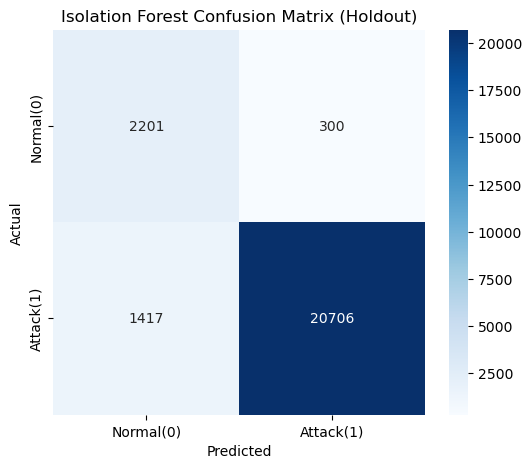

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(holdoutTrain, iso_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal(0)", "Attack(1)"],
            yticklabels=["Normal(0)", "Attack(1)"])
plt.title("Isolation Forest Confusion Matrix (Holdout)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Anomaly score distribution

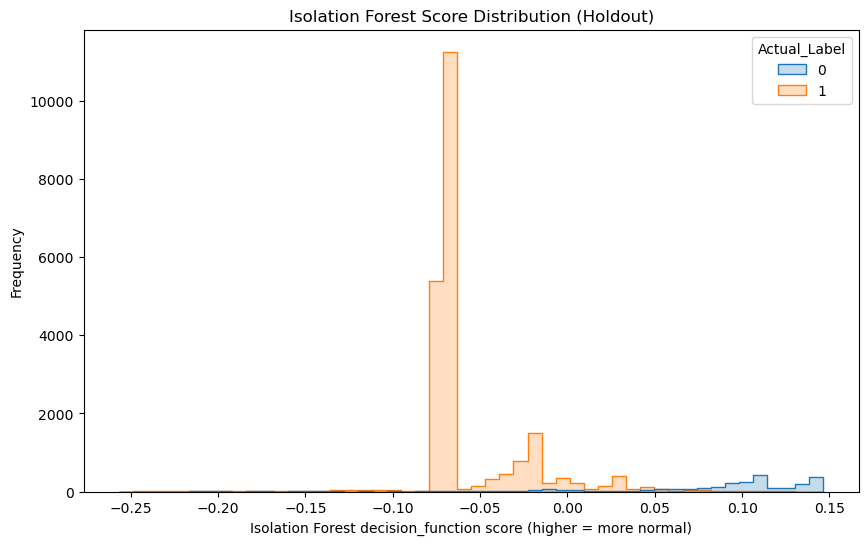

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Higher scores = more normal (typically)
scores = iso_detector.decision_function(holdoutX_ready)

score_df = pd.DataFrame({
    "Actual_Label": holdoutTrain,
    "IF_Score": scores
})

plt.figure(figsize=(10, 6))
sns.histplot(data=score_df, x="IF_Score", hue="Actual_Label", bins=50, element="step", stat="count")
plt.title("Isolation Forest Score Distribution (Holdout)")
plt.xlabel("Isolation Forest decision_function score (higher = more normal)")
plt.ylabel("Frequency")
plt.show()

### Saving model + preprocessor 

In [94]:
import joblib
import os

os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(iso_detector, "../outputs/models/isolation_forest_model.joblib")
joblib.dump(processor, "../outputs/models/preprocessor.joblib")

print("Saved Isolation Forest + preprocessor into ../outputs/models/ folder")

Saved Isolation Forest + preprocessor into ../outputs/models/ folder


### Evaluation Random Forest (Test set)

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Sanity check
print("fitX_ready:", fitX_ready.shape)
print("holdoutX_ready:", holdoutX_ready.shape)

# Re-train RF on the CURRENT feature space (93)
rf_detector = RandomForestClassifier(
    n_estimators=100,
    random_state=base_value,
    n_jobs=-1
)

rf_detector.fit(fitX_ready, fitTrain)

# Predict on holdout
rf_holdout_preds = rf_detector.predict(holdoutX_ready)

# Metrics
rf_holdout_acc = accuracy_score(holdoutTrain, rf_holdout_preds)
rf_holdout_prec = precision_score(holdoutTrain, rf_holdout_preds, average="weighted", zero_division=0)
rf_holdout_rec = recall_score(holdoutTrain, rf_holdout_preds, average="weighted", zero_division=0)
rf_holdout_f1 = f1_score(holdoutTrain, rf_holdout_preds, average="weighted", zero_division=0)

print("--- Random Forest (Holdout/Test) Report ---")
print(f"Holdout Accuracy: {rf_holdout_acc:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(holdoutTrain, rf_holdout_preds))
print("\nClassification Report:\n", classification_report(holdoutTrain, rf_holdout_preds))

fitX_ready: (19698, 93)
holdoutX_ready: (24624, 93)
--- Random Forest (Holdout/Test) Report ---
Holdout Accuracy: 0.9970

Confusion Matrix:
 [[ 2468    33]
 [   42 22081]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      2501
           1       1.00      1.00      1.00     22123

    accuracy                           1.00     24624
   macro avg       0.99      0.99      0.99     24624
weighted avg       1.00      1.00      1.00     24624



### Evaluation Isolation Forest 

In [75]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Safety: compute iso_binary if not already defined ---
if "iso_binary" not in globals():
  
    iso_pred = iso_detector.predict(holdoutX_ready)      # +1 normal, -1 attack
    iso_binary = (iso_pred == -1).astype(int)            # 1 attack, 0 normal

# --- Metrics on holdout ---
iso_holdout_acc  = accuracy_score(holdoutTrain, iso_binary)
iso_holdout_prec = precision_score(holdoutTrain, iso_binary, average="weighted", zero_division=0)
iso_holdout_rec  = recall_score(holdoutTrain, iso_binary, average="weighted", zero_division=0)
iso_holdout_f1   = f1_score(holdoutTrain, iso_binary, average="weighted", zero_division=0)

print("--- Isolation Forest (Holdout/Test) ---")
print(f"Holdout Accuracy: {iso_holdout_acc:.4f}")
print(f"Weighted Precision: {iso_holdout_prec:.4f}")
print(f"Weighted Recall:    {iso_holdout_rec:.4f}")
print(f"Weighted F1-score:  {iso_holdout_f1:.4f}")

print("\nConfusion Matrix:\n", confusion_matrix(holdoutTrain, iso_binary))
print("\nClassification Report:\n", classification_report(holdoutTrain, iso_binary))

--- Isolation Forest (Holdout/Test) ---
Holdout Accuracy: 0.9303
Weighted Precision: 0.9474
Weighted Recall:    0.9303
Weighted F1-score:  0.9357

Confusion Matrix:
 [[ 2201   300]
 [ 1417 20706]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.88      0.72      2501
           1       0.99      0.94      0.96     22123

    accuracy                           0.93     24624
   macro avg       0.80      0.91      0.84     24624
weighted avg       0.95      0.93      0.94     24624



### Confusion Matrix Heatmap (Seaborn Plot)

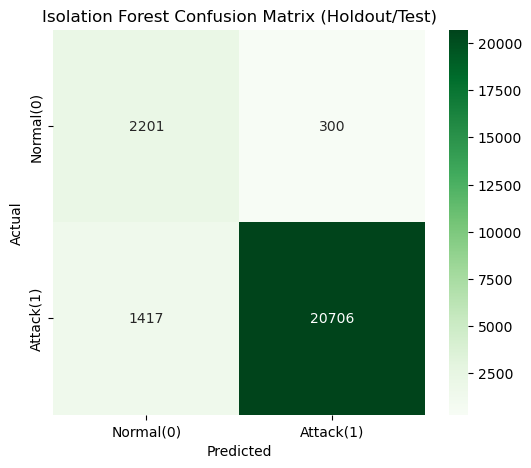

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_iso = confusion_matrix(holdoutTrain, iso_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_iso, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal(0)", "Attack(1)"],
            yticklabels=["Normal(0)", "Attack(1)"])
plt.title("Isolation Forest Confusion Matrix (Holdout/Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Build a Clean Comparison Table (Dummy vs RF vs Isolation Forest)

In [77]:
import pandas as pd

comparison_data = {
    "Metric": [
        "Accuracy (Validation)",
        "Accuracy (Holdout/Test)",
        "Precision (Weighted, Holdout)",
        "Recall (Weighted, Holdout)",
        "F1-score (Weighted, Holdout)"
    ],
    "Baseline (Dummy)": [
        f"{base_acc:.4f}" if "base_acc" in globals() else "N/A",
        "N/A",
        "N/A",
        "N/A",
        "N/A"
    ],
    "Random Forest": [
        f"{rf_acc:.4f}" if "rf_acc" in globals() else "N/A",
        f"{rf_holdout_acc:.4f}" if "rf_holdout_acc" in globals() else "N/A",
        f"{rf_holdout_prec:.4f}" if "rf_holdout_prec" in globals() else "N/A",
        f"{rf_holdout_rec:.4f}" if "rf_holdout_rec" in globals() else "N/A",
        f"{rf_holdout_f1:.4f}" if "rf_holdout_f1" in globals() else "N/A"
    ],
    "Isolation Forest": [
        "N/A",
        f"{iso_holdout_acc:.4f}",
        f"{iso_holdout_prec:.4f}",
        f"{iso_holdout_rec:.4f}",
        f"{iso_holdout_f1:.4f}"
    ]
}

performance_df = pd.DataFrame(comparison_data)

print("--- Model Comparison Table (Validation + Holdout) ---")
print(performance_df.to_string(index=False))

--- Model Comparison Table (Validation + Holdout) ---
                       Metric Baseline (Dummy) Random Forest Isolation Forest
        Accuracy (Validation)           0.5015        0.5000              N/A
      Accuracy (Holdout/Test)              N/A        0.9970           0.9303
Precision (Weighted, Holdout)              N/A        0.9970           0.9474
   Recall (Weighted, Holdout)              N/A        0.9970           0.9303
 F1-score (Weighted, Holdout)              N/A        0.9970           0.9357


### Recomputing Random Forest Validation Metrics using the Real Data Pipeline

In [78]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Predicting on validation using the current RF trained on real preprocessed features
rf_val_preds = rf_detector.predict(valiX_ready)

rf_acc_real = accuracy_score(valiTrain, rf_val_preds)
rf_prec_real = precision_score(valiTrain, rf_val_preds, average="weighted", zero_division=0)
rf_rec_real = recall_score(valiTrain, rf_val_preds, average="weighted", zero_division=0)
rf_f1_real = f1_score(valiTrain, rf_val_preds, average="weighted", zero_division=0)

print("--- Random Forest (Validation, REAL pipeline) ---")
print(f"Validation Accuracy: {rf_acc_real:.4f}")
print("Confusion Matrix:\n", confusion_matrix(valiTrain, rf_val_preds))
print("\nClassification Report:\n", classification_report(valiTrain, rf_val_preds))

--- Random Forest (Validation, REAL pipeline) ---
Validation Accuracy: 0.9976
Confusion Matrix:
 [[ 7917    88]
 [  102 70688]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8005
           1       1.00      1.00      1.00     70790

    accuracy                           1.00     78795
   macro avg       0.99      0.99      0.99     78795
weighted avg       1.00      1.00      1.00     78795



### Adding Baseline

In [79]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_detector = DummyClassifier(strategy="most_frequent", random_state=base_value)
dummy_detector.fit(fitX_ready, fitTrain)

dummy_holdout_preds = dummy_detector.predict(holdoutX_ready)
dummy_holdout_acc = accuracy_score(holdoutTrain, dummy_holdout_preds)

print("--- Dummy Baseline (Holdout/Test) ---")
print("Holdout Accuracy:", f"{dummy_holdout_acc:.4f}")

--- Dummy Baseline (Holdout/Test) ---
Holdout Accuracy: 0.8984


### Comparison Table

In [80]:
import pandas as pd

comparison_data_updated = {
    "Metric": [
        "Accuracy (Validation)",
        "Accuracy (Holdout/Test)",
        "Precision (Weighted, Holdout)",
        "Recall (Weighted, Holdout)",
        "F1-score (Weighted, Holdout)"
    ],
    "Baseline (Dummy)": [
        f"{dummy_detector.score(valiX_ready, valiTrain):.4f}" if "dummy_detector" in globals() else "N/A",
        f"{dummy_holdout_acc:.4f}" if "dummy_holdout_acc" in globals() else "N/A",
        "N/A", "N/A", "N/A"
    ],
    "Random Forest": [
        f"{rf_acc_real:.4f}",
        f"{rf_holdout_acc:.4f}",
        f"{rf_holdout_prec:.4f}",
        f"{rf_holdout_rec:.4f}",
        f"{rf_holdout_f1:.4f}"
    ],
    "Isolation Forest": [
        "N/A",
        f"{iso_holdout_acc:.4f}",
        f"{iso_holdout_prec:.4f}",
        f"{iso_holdout_rec:.4f}",
        f"{iso_holdout_f1:.4f}"
    ]
}

performance_df_updated = pd.DataFrame(comparison_data_updated)
print("--- Updated Model Comparison Table (REAL) ---")
print(performance_df_updated.to_string(index=False))

--- Updated Model Comparison Table (REAL) ---
                       Metric Baseline (Dummy) Random Forest Isolation Forest
        Accuracy (Validation)           0.8984        0.9976              N/A
      Accuracy (Holdout/Test)           0.8984        0.9970           0.9303
Precision (Weighted, Holdout)              N/A        0.9970           0.9474
   Recall (Weighted, Holdout)              N/A        0.9970           0.9303
 F1-score (Weighted, Holdout)              N/A        0.9970           0.9357


### Random Forest Confusion Matrix Heatmap

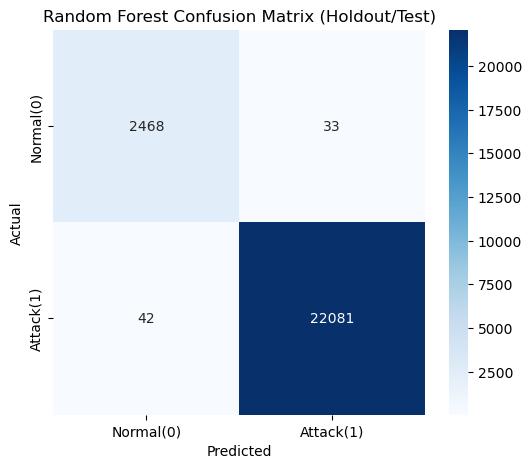

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(holdoutTrain, rf_holdout_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal(0)", "Attack(1)"],
            yticklabels=["Normal(0)", "Attack(1)"])
plt.title("Random Forest Confusion Matrix (Holdout/Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### RF Probability Score Distribution

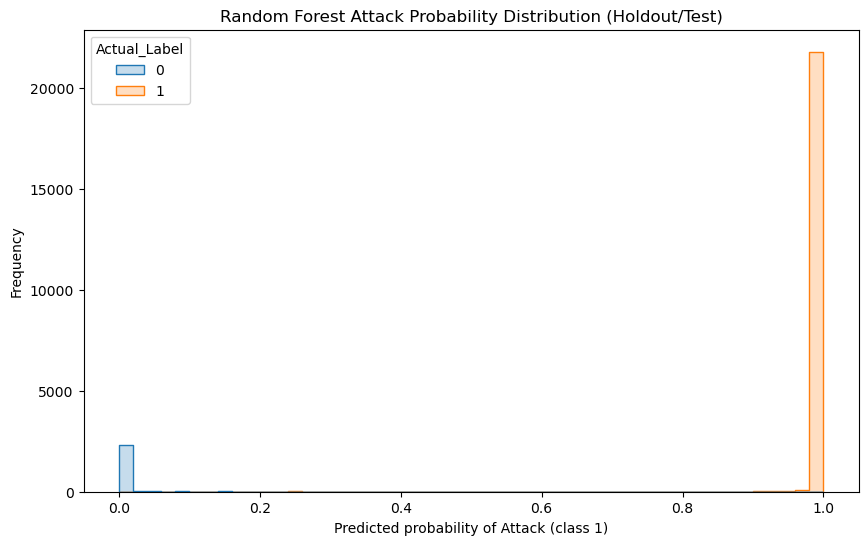

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rf_scores_holdout = rf_detector.predict_proba(holdoutX_ready)[:, 1]

rf_results_holdout = pd.DataFrame({
    "Actual_Label": holdoutTrain,
    "RF_Attack_Prob": rf_scores_holdout
})

plt.figure(figsize=(10, 6))
sns.histplot(data=rf_results_holdout, x="RF_Attack_Prob", hue="Actual_Label",
             bins=50, element="step", stat="count")
plt.title("Random Forest Attack Probability Distribution (Holdout/Test)")
plt.xlabel("Predicted probability of Attack (class 1)")
plt.ylabel("Frequency")
plt.show()

### Binary relabelling of RT IoT2022 traffic classes into benign and attack categories 

In [91]:
import pandas as pd

table5_df = pd.DataFrame({
    "RT-IoT2022 Attack_type": ["Thing_Speak", "MQTT_Publish", "Wipro_bulb", "All other Attack_type values"],
    "binary_label": [0, 0, 0, 1],
    "Category": ["Benign", "Benign", "Benign", "Attack"]
})

table5_df

,RT-IoT2022 Attack_type,binary_label,Category
0,Thing_Speak,0,Benign
1,MQTT_Publish,0,Benign
2,Wipro_bulb,0,Benign
3,All other Attack_type values,1,Attack


### Save Key Outputs (Models + Tables + Figures)

In [93]:
import os
import joblib

os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/metrics", exist_ok=True)

joblib.dump(rf_detector, "../outputs/models/random_forest_model.joblib")

# Saving updated comparison table
performance_df_updated.to_csv("../outputs/metrics/model_comparison.csv", index=False)

print("Saved  Random Forest (RF) model + comparison table into ../outputs/")

Saved  Random Forest (RF) model + comparison table into ../outputs/
